## Setup

In [20]:
%load_ext autoreload
%autoreload 2

# To ensure reproducibility
seed = 7214

Failed to reload module 'src.utils.models' from file '/workspaces/TFM/src/utils/models/__init__.py'
Traceback (most recent call last):
  File "/opt/conda/envs/tfm_python/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/opt/conda/envs/tfm_python/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/opt/conda/envs/tfm_python/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/workspaces/TFM/src/utils/models/__init__.py", line 5, in <module>
    from .training_and_evaluation import (
ImportError: cannot import name 'hyperparameters_search_space' 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of src.utils.models failed: Traceback (most recent call last):
  File "/opt/conda/envs/tfm_python/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/opt/conda/envs/tfm_python/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/opt/conda/envs/tfm_python/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/workspaces/TFM/src/utils/models/__init__.py", line 5, in <module>
    from .training_and_evaluation import (
ImportError: cannot import name 'hyperparameters_search_space' from 'src.utils.models.training_and_evaluation' (/workspaces

Set up the working environment:

In [21]:
# Import path libraries
import os
import sys
import pathlib

# Modify this flag variable to control whether the irrelevant features are 
# filtered or not
enable_filter = True

# Define paths
project_path = pathlib.Path("../").resolve()
data_path = project_path / "data" / "clean" / "09proteomic_data_with_target.parquet"

results_path = project_path / "results" / "models" / "proteomic_data"
results_path.mkdir(parents=True, exist_ok=True)

# Add the project path to sys.path if it's not already there
if str(project_path) not in sys.path:
    sys.path.append(str(project_path))

print(f"Loading data from: {data_path}")
print(f"Saving results to: {results_path}")

Loading data from: /workspaces/TFM/data/clean/09proteomic_data_with_target.parquet
Saving results to: /workspaces/TFM/results/models/proteomic_data


Load libraries:

In [22]:
# DATA WRANGLING, STATISTICS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy.stats import uniform, randint, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, 
                            ExtraTreesClassifier, 
                            AdaBoostClassifier, 
                            GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (roc_curve, 
                            precision_recall_curve, 
                            roc_auc_score, 
                            average_precision_score)

# CUSTOM MODULES
from src.utils.models import *

## Data

Load proteomic data:

In [23]:
# Load dataset
df = pd.read_parquet(data_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 488 entries, 0 to 487
Columns: 364 entries, code to AF_recurrence
dtypes: float64(362), object(2)
memory usage: 1.4+ MB


Let's transform the categorical features `object` data type into `category` and check their values:

In [24]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    print(f"Categories of column '{col}': {df[col].cat.categories.tolist()}")

Categories of column 'intervention': ['control', 'intervention']
Categories of column 'AF_recurrence': ['no', 'yes']


Separate the features from the target class:

In [25]:
# Drop the target class and the non-informative features
X = df.drop([
    "code",
    "AF_recurrence" 
            ], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train ($80 \%$) and test ($20 \%$) sets:

In [26]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

# Training and optimization

## Training and optimization

`n_trials` per model with stratified `n_cv`-fold cross validation:

In [27]:
# Number of trials for hyperparameter search
n_trials = 30

# Number of splits
n_cv = 3

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=42)

Define metrics to evaluate:

In [28]:
# Set up the scoring dictionary for cross-validation
scoring_dict = {
    'ROC-AUC': 'roc_auc',
    'PR-AUC': 'average_precision'
}

objective_metric = 'PR-AUC'

#### Logistic Regression (Elastic Net)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/sit

Performing internal and external cross-validation...
relevant features:  ['FAM3C', 'EFEMP1', 'SELE', 'BOC', 'F7', 'OLR1', 'MPHOSPH8', 'CNTN1', 'CCL16', 'NTproBNP', 'PGLYRP1', 'TNNI3', 'EPHX2', 'TGM2', 'TFRC', 'IL19', 'TNF', 'DLK1', 'SLITRK6', 'GHRL', 'KIT', 'DPP7', 'CDH1', 'LBP', 'LILRB5', 'IL6', 'CRX', 'GH1', 'VSTM2L', 'HYAL1', 'CRTAC1', 'MFAP3', 'PON2', 'ITIH3', 'SPON2', 'MMP7', 'MTPN', 'REG1B', 'CD55', 'AMY2B', 'DPP4', 'NID1', 'EDIL3', 'PROC', 'CPA1', 'MSTN', 'GAS6', 'PTN', 'CST6', 'CHI3L1', 'SERPINA12', 'DEFA1_DEFA1B', 'ICAM5', 'TYMP', 'HMOX1', 'EGFR', 'FUCA1', 'GUSB', 'GPR37', 'THOP1', 'RNASET2', 'IL6R', 'SELP', 'FCN2', 'CLTA', 'IL2RA', 'LGALS3']


relevant features:  ['ACE2', 'ACTA2', 'ADAM15', 'ADH4', 'AKR1C4', 'BAG6', 'CA5A', 'CEACAM8', 'CEBPB', 'CEP43', 'CHEK2', 'CLEC1A', 'CNPY2', 'COMT', 'CRHR1', 'CTF1', 'CTSH', 'DCN', 'DNAJB8', 'DUOX2', 'ENTPD5', 'ENTPD6', 'FABP6', 'GLO1', 'GP2', 'GRK5', 'GYS1', 'GZMH', 'HK2', 'HNRNPK', 'IRAG2', 'ITGB1BP2', 'NPPB', 'PAG1', 'RCOR1', 'S100P', 

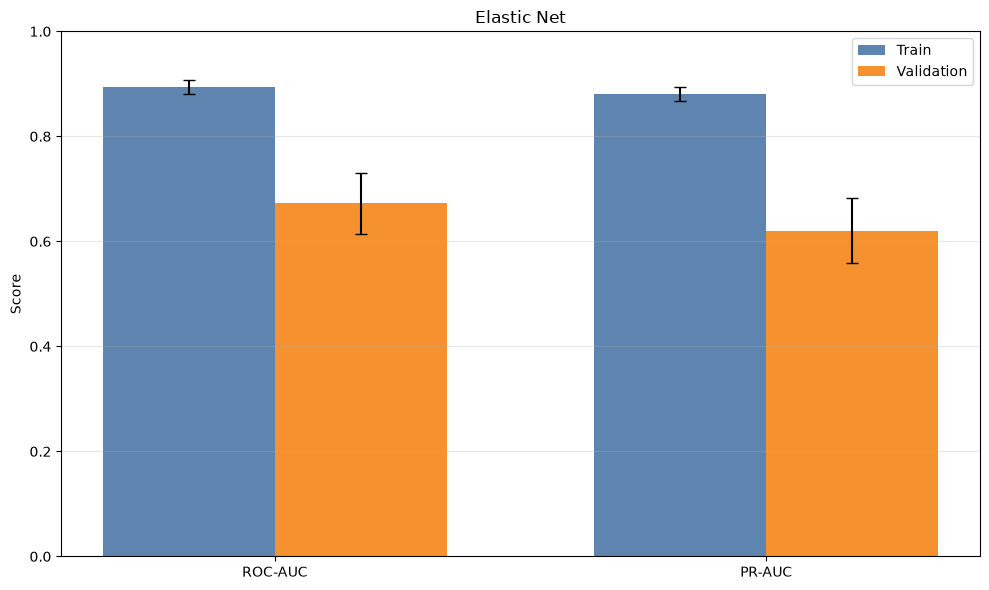

In [ ]:
# Get the preprocessor
preprocessor_EN = get_full_preprocessor(X_train, seed=seed)

# Build the pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed, solver='saga', max_iter=1000))
])

# Hyperparameters search space
params_EN = proteomic_hyperparameters_search_space['EN']

(
    optimized_EN,
    cv_results_EN,
    fpr_EN, tpr_EN,
    precs_EN, recs_EN
) = optimize_model_random_search(
    pipeline=pipe_EN,
    param_distributions=params_EN,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    metrics_dict=scoring_dict,
    aim=scoring_dict[objective_metric],
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_EN, output_dir=results_path, identifier='EN')
plot_internal_validation(
    cv_results_EN,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='Elastic Net'
)

relevant_cols, irrelevant_cols = get_relevant_features(optimized_EN)
print('relevant features: ', relevant_cols)
print('\n')
print('relevant features: ', irrelevant_cols)

if enable_filter:
    X_train_filtered = X_train.drop(columns=irrelevant_cols)
    X_test_filtered = X_test.drop(columns=irrelevant_cols)
else:
    X_train_filtered = X_train
    X_test_filtered = X_test

#### Support Vector Machine

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_bas

Performing internal and external cross-validation...


/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'SVM'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.910775  0.016445
 1   PR-AUC  Validation  0.764863  0.062289
 2  ROC-AUC       Train  0.931815  0.014417
 3  ROC-AUC  Validation  0.801749  0.027550)

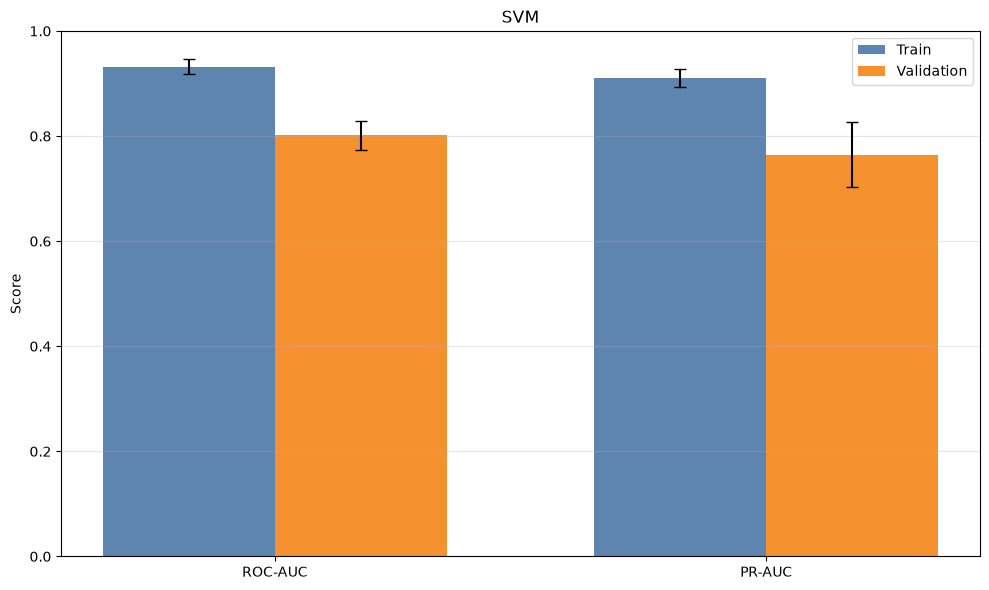

In [30]:
# Get preprocessor
preprocessor_SVM = get_full_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed, max_iter=1000))
])

# Hyperparameters search space
params_dist_SVM = proteomic_hyperparameters_search_space['SVM']

(
    optimized_SVM,
    cv_results_SVM,
    fpr_SVM, tpr_SVM,
    precs_SVM, recs_SVM
) = optimize_model_random_search(
    pipeline=pipe_SVM,
    param_distributions=params_dist_SVM,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_SVM, output_dir=results_path, identifier='SVM')
plot_internal_validation(
    cv_results_SVM,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='SVM'
)

#### Decision Tree

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Performing internal and external cross-validation...


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Decision Tree'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.886689  0.026199
 1   PR-AUC  Validation  0.577620  0.032034
 2  ROC-AUC       Train  0.917990  0.016653
 3  ROC-AUC  Validation  0.650077  0.029823)

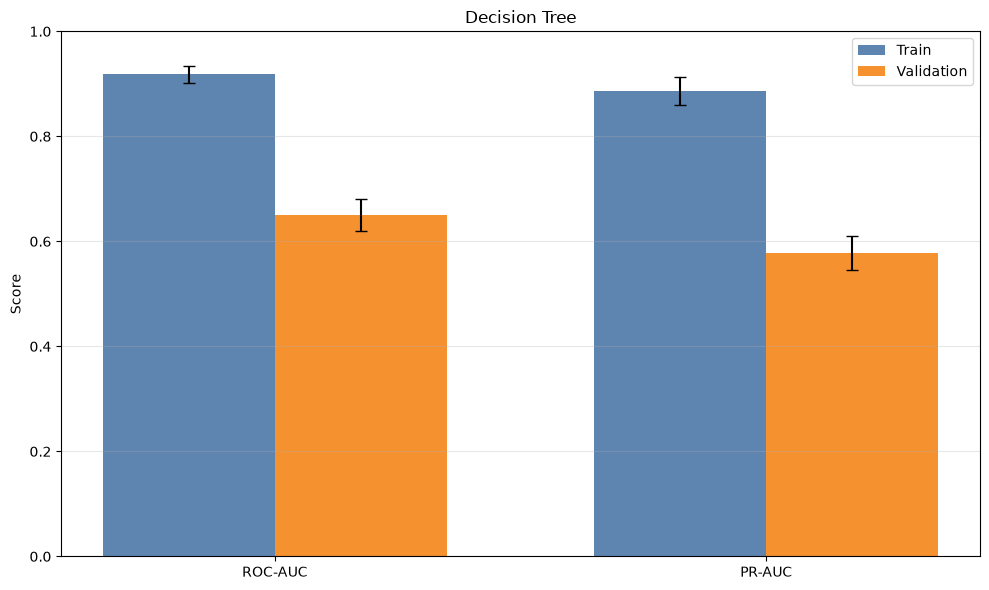

In [31]:
# Get the preprocessor
preprocessor_DT = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_DT = Pipeline(steps=[
    ('preprocessor', preprocessor_DT),
    ('clf', DecisionTreeClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_DT = proteomic_hyperparameters_search_space['DT']

(
    optimized_DT,
    cv_results_DT,
    fpr_DT, tpr_DT,
    precs_DT, recs_DT
) = optimize_model_random_search(
    pipeline=pipe_DT,
    param_distributions=params_dist_DT,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_DT, output_dir=results_path, identifier='DT')
plot_internal_validation(
    cv_results_DT,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='Decision Tree'
)

#### Random Forest

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Performing internal and external cross-validation...


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Random Forest'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.998074  0.000379
 1   PR-AUC  Validation  0.703245  0.040616
 2  ROC-AUC       Train  0.998402  0.000350
 3  ROC-AUC  Validation  0.748423  0.026839)

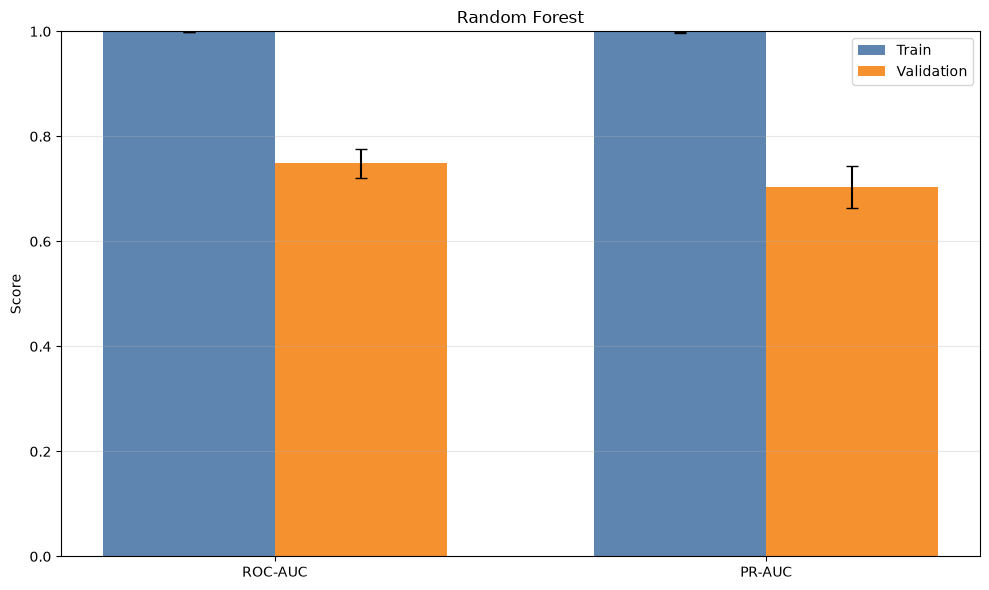

In [32]:
# Get the preprocessor
preprocessor_RF = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_RF = proteomic_hyperparameters_search_space['RF']

(
    optimized_RF,
    cv_results_RF,
    fpr_RF, tpr_RF,
    precs_RF, recs_RF
) = optimize_model_random_search(
    pipeline=pipe_RF,
    param_distributions=params_dist_RF,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_RF, output_dir=results_path, identifier='RF')
plot_internal_validation(
    cv_results_RF,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='Random Forest'
)

#### Extra Trees

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Performing internal and external cross-validation...


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Extra Trees'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.965235  0.010922
 1   PR-AUC  Validation  0.711373  0.053012
 2  ROC-AUC       Train  0.968919  0.009058
 3  ROC-AUC  Validation  0.754173  0.043145)

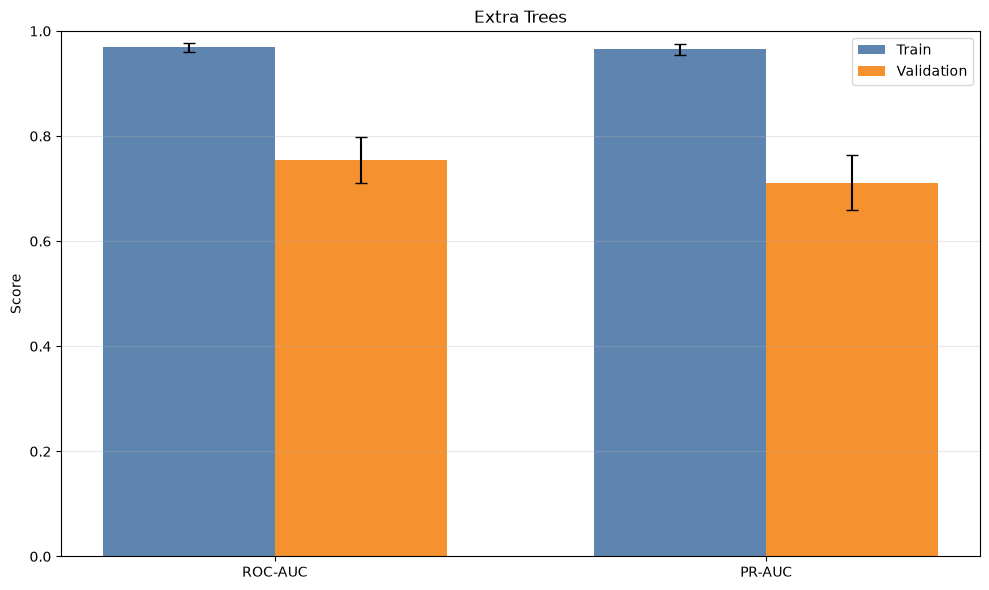

In [33]:
# Get the preprocessor
preprocessor_ET = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor_ET),
    ('clf', ExtraTreesClassifier(random_state=seed))
])

# ExtraTrees uses bootstrap=False by default; max_samples is only valid with bootstrap=True.
params_dist_ET = {
    key: value
    for key, value in proteomic_hyperparameters_search_space['RF'].items()
    if key != 'clf__max_samples'
}

(
    optimized_ET,
    cv_results_ET,
    fpr_ET, tpr_ET,
    precs_ET, recs_ET
) = optimize_model_random_search(
    pipeline=pipe_ET,
    param_distributions=params_dist_ET,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_ET, output_dir=results_path, identifier='ET')
plot_internal_validation(
    cv_results_ET,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='Extra Trees'
)

#### Adaptive Boosting

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Performing internal and external cross-validation...


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'AdaBoost'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  1.000000  0.000000
 1   PR-AUC  Validation  0.639295  0.048916
 2  ROC-AUC       Train  1.000000  0.000000
 3  ROC-AUC  Validation  0.698520  0.047289)

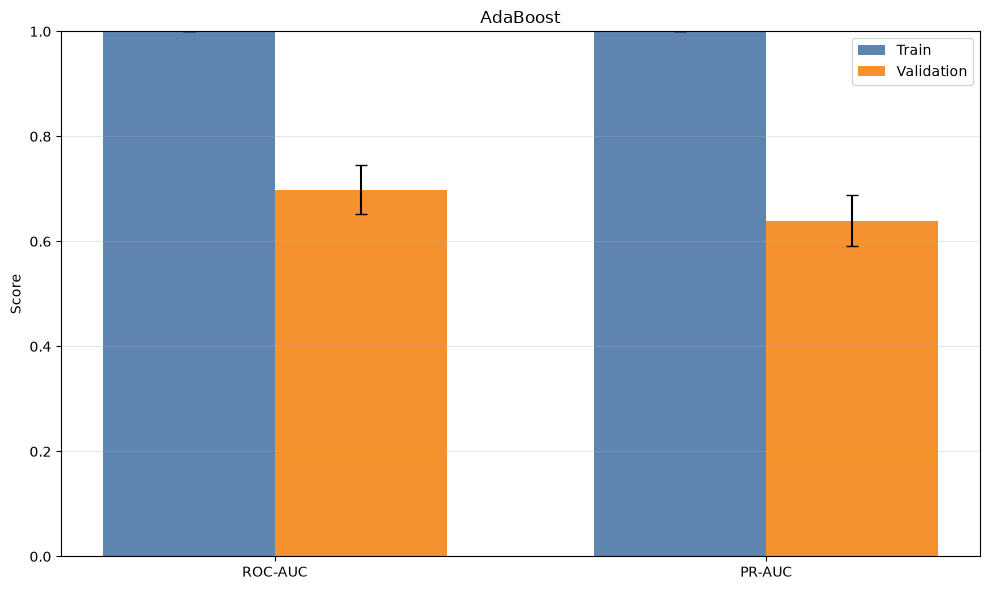

In [34]:
# Get the preprocessor
preprocessor_AB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_AB = Pipeline(steps=[
    ('preprocessor', preprocessor_AB),
    ('clf', AdaBoostClassifier(random_state=seed, estimator=DecisionTreeClassifier(random_state=seed)))
])

# Hyperparameters search space
params_dist_AB = proteomic_hyperparameters_search_space['AB']

(
    optimized_AB,
    cv_results_AB,
    fpr_AB, tpr_AB,
    precs_AB, recs_AB
) = optimize_model_random_search(
    pipeline=pipe_AB,
    param_distributions=params_dist_AB,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_AB, output_dir=results_path, identifier='AB')
plot_internal_validation(
    cv_results_AB,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='AdaBoost'
)

#### Gradient Boosting

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Performing internal and external cross-validation...


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Gradient Boosting'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  1.000000  0.000000
 1   PR-AUC  Validation  0.700950  0.050584
 2  ROC-AUC       Train  1.000000  0.000000
 3  ROC-AUC  Validation  0.752626  0.042878)

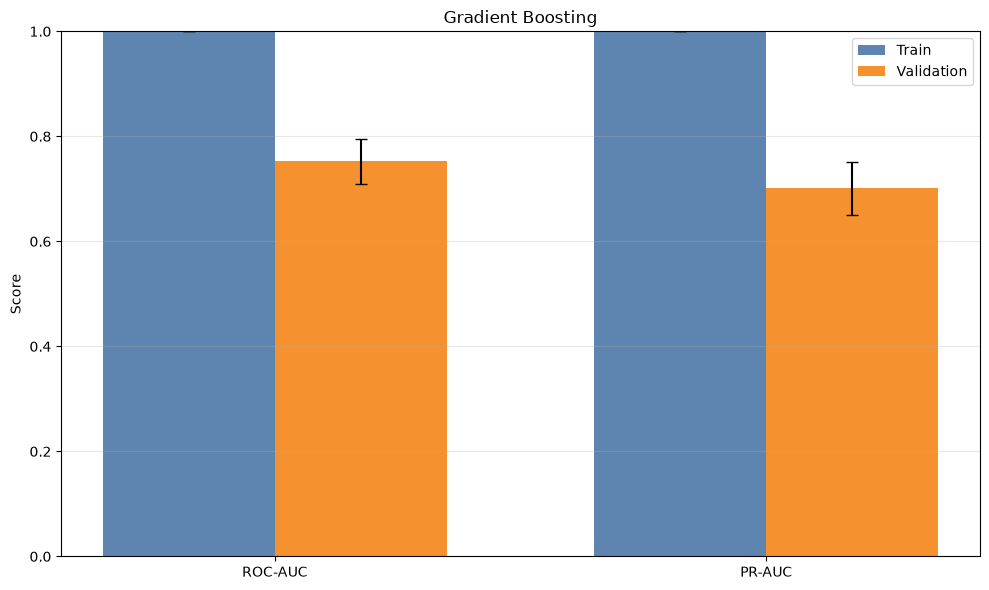

In [35]:
# Get the preprocessor
preprocessor_GB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_GB = Pipeline(steps=[
    ('preprocessor', preprocessor_GB),
    ('clf', GradientBoostingClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_GB = proteomic_hyperparameters_search_space['GB']

(
    optimized_GB,
    cv_results_GB,
    fpr_GB, tpr_GB,
    precs_GB, recs_GB
) = optimize_model_random_search(
    pipeline=pipe_GB,
    param_distributions=params_dist_GB,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_GB, output_dir=results_path, identifier='GB')
plot_internal_validation(
    cv_results_GB,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='Gradient Boosting'
)

#### Multi-Layer Perceptron

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Performing internal and external cross-validation...


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Multi-Layer Perceptron'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.935415  0.039656
 1   PR-AUC  Validation  0.758190  0.061549
 2  ROC-AUC       Train  0.943379  0.035204
 3  ROC-AUC  Validation  0.804939  0.041807)

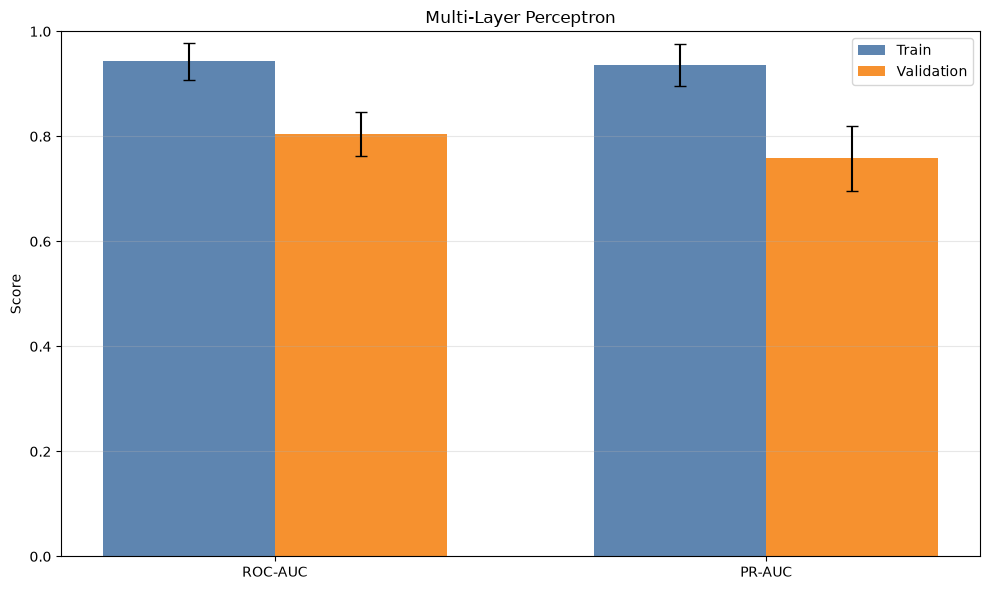

In [36]:
# Get the preprocessor
preprocessor_MLP = get_full_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_MLP = Pipeline(steps=[
    ('preprocessor', preprocessor_MLP),
    ('clf', MLPClassifier(random_state=seed, max_iter=1000, early_stopping=True, validation_fraction=0.1))
])

# Hyperparameters search space
params_dist_MLP = proteomic_hyperparameters_search_space['MLP']

(
    optimized_MLP,
    cv_results_MLP,
    fpr_MLP, tpr_MLP,
    precs_MLP, recs_MLP
) = optimize_model_random_search(
    pipeline=pipe_MLP,
    param_distributions=params_dist_MLP,
    X_train=X_train_filtered, y_train=y_train,
    X_test=X_test_filtered, y_test=y_test,
    metrics_dict=scoring_dict,
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
)

save_model(fitted_pipeline=optimized_MLP, output_dir=results_path, identifier='MLP')
plot_internal_validation(
    cv_results_MLP,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title='Multi-Layer Perceptron'
)

## Save results

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Precision-Recall curves'}, xlabel='Recall', ylabel='Precision'>)

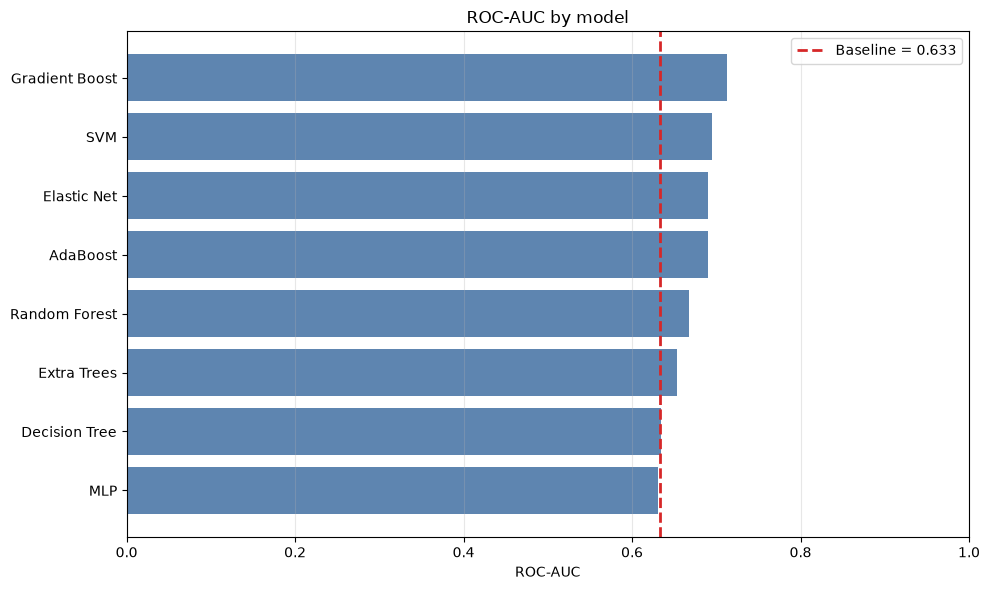

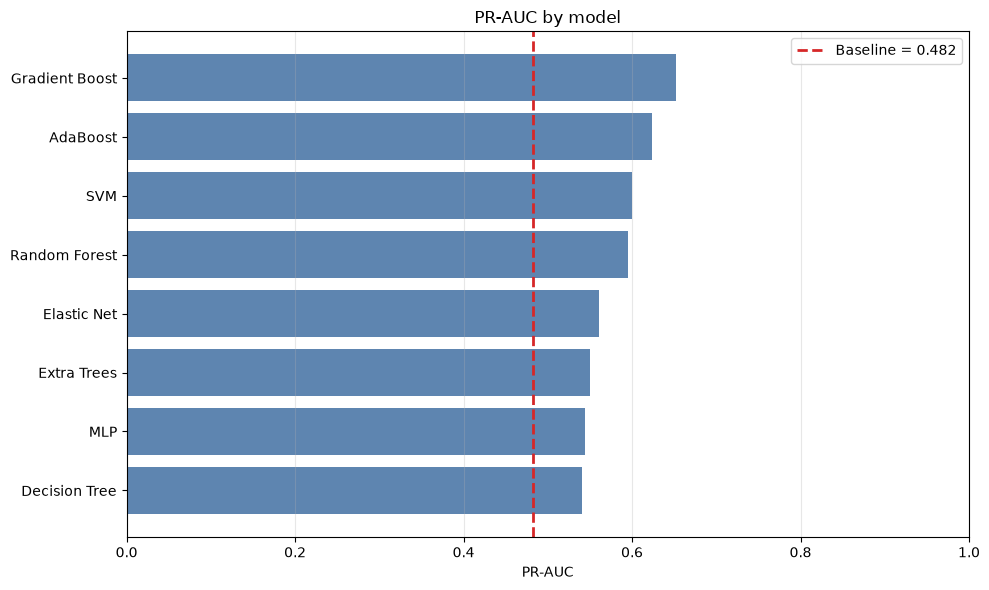

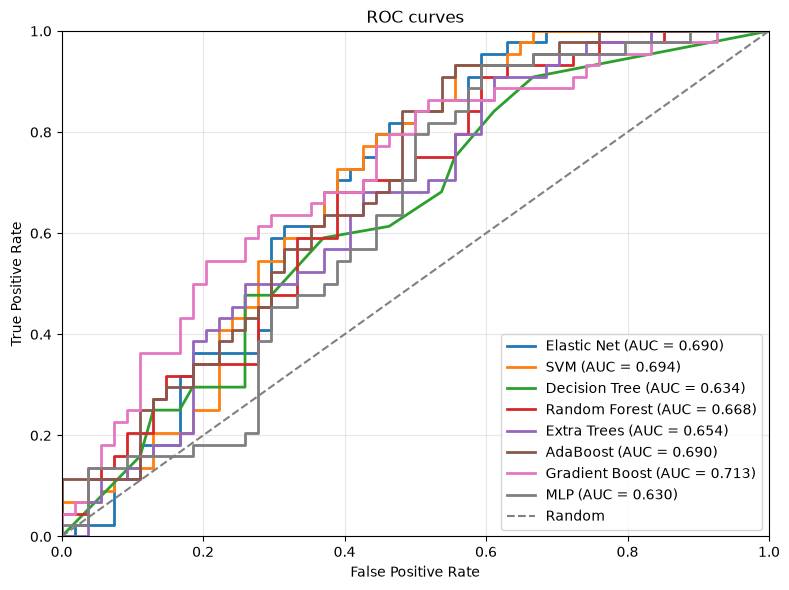

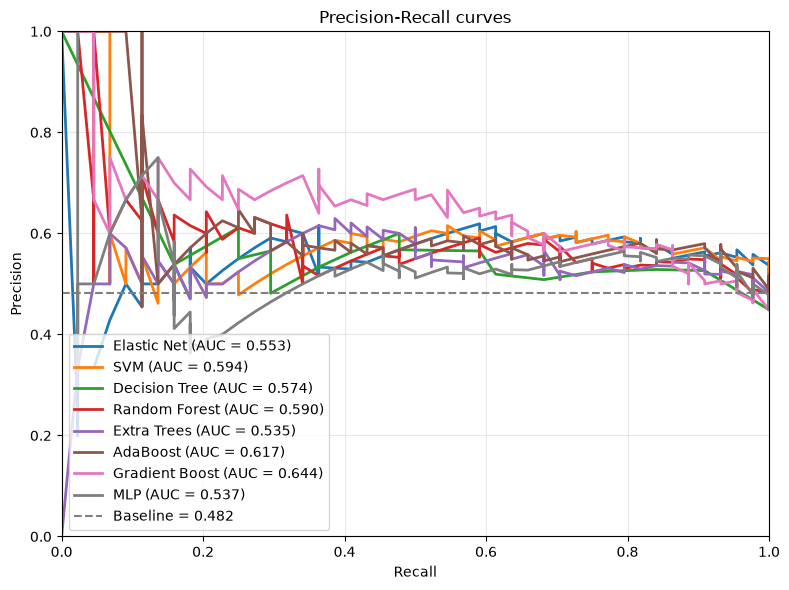

In [37]:
models = ['Elastic Net', 'SVM', 'Decision Tree', 'Random Forest', 'Extra Trees', 'AdaBoost', 'Gradient Boost', 'MLP']

models_dict = {
    'Elastic Net': cv_results_EN,
    'SVM': cv_results_SVM,
    'Decision Tree': cv_results_DT,
    'Random Forest': cv_results_RF,
    'Extra Trees': cv_results_ET,
    'AdaBoost': cv_results_AB,
    'Gradient Boost': cv_results_GB,
    'MLP': cv_results_MLP,
}

results_df = save_metrics_results(models_dict=models_dict, output_dir=results_path)
results_df.head()

roc_auc_baseline = 0.633
pr_auc_baseline = 0.482

plot_external_validation(
    results_df,
    baseline=roc_auc_baseline,
    metric='ROC-AUC',
    title='ROC-AUC by model'
)

plot_external_validation(
    results_df,
    baseline=pr_auc_baseline,
    metric='PR-AUC',
    title='PR-AUC by model'
)

fpr = [fpr_EN, fpr_SVM, fpr_DT, fpr_RF, fpr_ET, fpr_AB, fpr_GB, fpr_MLP]
tpr = [tpr_EN, tpr_SVM, tpr_DT, tpr_RF, tpr_ET, tpr_AB, tpr_GB, tpr_MLP]
roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', output_dir=results_path)

precs = [precs_EN, precs_SVM, precs_DT, precs_RF, precs_ET, precs_AB, precs_GB, precs_MLP]
recs = [recs_EN, recs_SVM, recs_DT, recs_RF, recs_ET, recs_AB, recs_GB, recs_MLP]
pr_results = save_curves_results(models, recs, precs, curve_type='pr', output_dir=results_path)

plot_roc_curves(
    roc_results,
    title='ROC curves'
)

plot_pr_curves(
    pr_results,
    baseline= pr_auc_baseline,
    title='Precision-Recall curves'
)